In [3]:
import subprocess
subprocess.run(['pip','install','yfinance','pandas','matplotlib','seaborn'],
               capture_output=True)

print

<function print(*args, sep=' ', end='\n', file=None, flush=False)>

In [8]:
import yfinance as yf
import pandas as pd

tickers = ['TD.TO','RY.TO','BMO.TO','BNS.TO','CM.TO','NA.To']
data = yf.download(tickers, start='2022-01-01',end='2024-12-31')
print(data.shape)
print(data.columns.get_level_values(0).unique())
data['Close'].head()

[*********************100%***********************]  6 of 6 completed

(751, 30)
Index(['Close', 'High', 'Low', 'Open', 'Volume'], dtype='object', name='Price')


Ticker,BMO.TO,BNS.TO,CM.TO,NA.TO,RY.TO,TD.TO
Date,,,,,,
2022-01-04,115.793533,70.977959,60.689159,84.554405,115.959709,81.503197
2022-01-05,114.890617,70.493599,61.455753,83.796562,117.213867,81.995407
2022-01-06,116.417328,71.290474,62.753639,83.609238,118.476509,82.495827
2022-01-07,117.468002,71.477974,63.625671,84.937584,120.120506,82.884850
2022-01-10,117.418755,71.040474,63.702721,84.111626,120.781464,82.545502


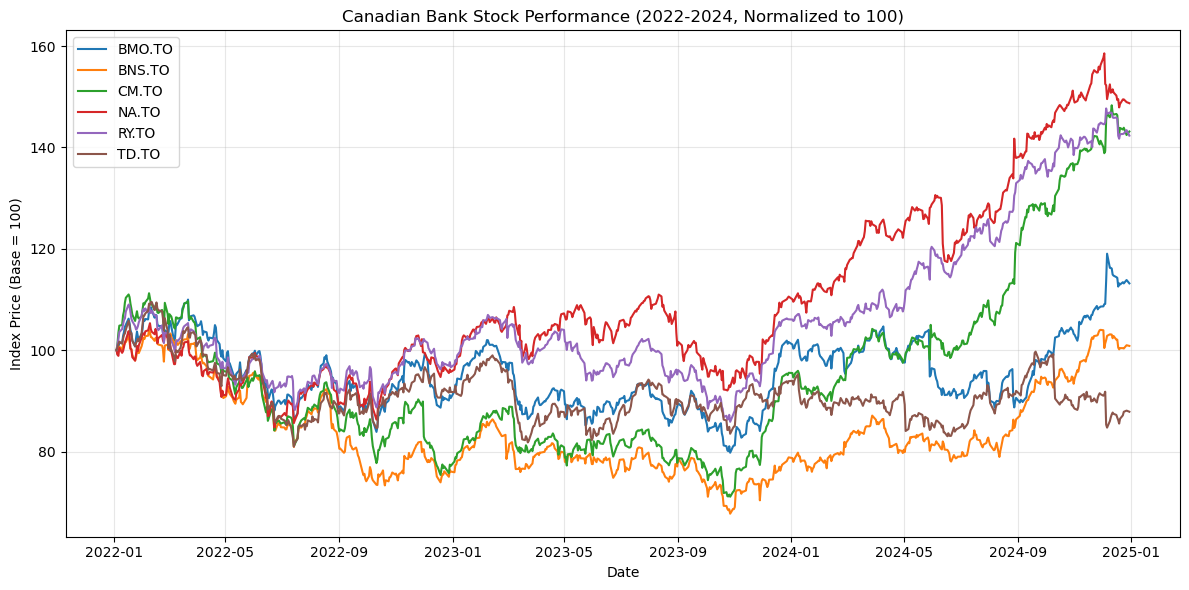

In [17]:
import matplotlib.pyplot as plt
#only get close price
close = data['Close']
# normalized:每家银行从100 开始（2022.01.04）看涨跌,Relative Performance Index
normalized = (close / close.iloc[0])*100
plt.figure(figsize=(12,6))
for ticker in normalized.columns:
    plt.plot(normalized.index,normalized[ticker],label=ticker)


plt.title('Canadian Bank Stock Performance (2022-2024, Normalized to 100)')
plt.xlabel('Date')
plt.ylabel('Index Price (Base = 100)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('bank_performance.png', dpi=150)
plt.show()



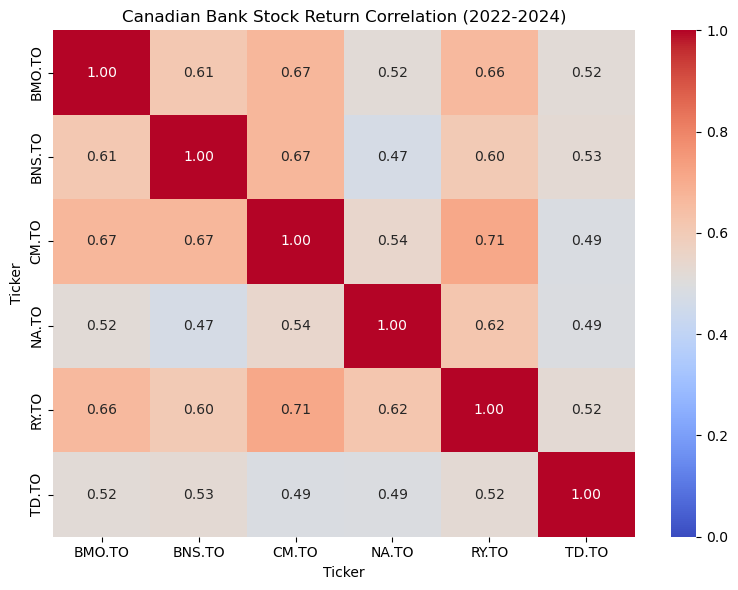

In [23]:
import seaborn as sns
#计算收盘价的日收益率
returns = close.pct_change().dropna()
#计算相关性矩阵
corr_matrix = returns.corr()
#hotspot 
plt.figure(figsize=(8,6))
sns.heatmap(corr_matrix,
            annot=True,       #显示数字
            fmt='.2f',        #保留两位小数
            cmap='coolwarm',  # 颜色 ：蓝=底相关，红=高相关
            vmin=0,vmax=1)


plt.title('Canadian Bank Stock Return Correlation (2022-2024)')
plt.tight_layout()
plt.savefig('correlation_matrix,png',dpi=150)
plt.show()

In [ ]:
import numpy as np
# annual return volatility
annual_vol=returns.std()*np.sqrt(252)*100
print('Annual return')
print(annual_vol.round(2).sort_values(ascending=False))

#Beta: TSX Composite
tsx = yf.download('^GSPTSE', start='2022-01-01', end='2024-12-31')['Close']
tsx_returns = tsx.pct_change().dropna()
# Beta
print("\n=== Beta (relate to TSX) ===")
betas = {}
for ticker in returns.columns:
    aligned = pd.concat([returns[ticker], tsx_returns], axis=1).dropna()
    aligned.columns = ['bank','tsx']

    #Beta = Cov(bank,tsx)/Var(tsx)
    cov = aligned.cov().iloc[0,1]
    var = aligned['tsx'].var()
    betas[ticker] = round(cov / var, 3)

beta_df = pd.Series(betas).sort_values(ascending=False)
print(beta_df)

[*********************100%***********************]  1 of 1 completed

Annual return
Ticker
CM.TO     19.14
BMO.TO    18.71
TD.TO     17.95
NA.TO     17.77
BNS.TO    17.21
RY.TO     14.95
dtype: float64

=== Beta (relate to TSX) ===
BMO.TO    1.023
CM.TO     0.961
BNS.TO    0.852
TD.TO     0.849
NA.TO     0.832
RY.TO     0.815
dtype: float64


In [47]:
import pandas as pd

df = pd.read_excel('C:/Users/lenovo/Documents/financials.xlsx')
print(df)
print('\n数据类型：')
print(df.dtypes)

df[['ROE', 'NIM', 'CET1', 'PCL_ratio']] = df[['ROE', 'NIM', 'CET1', 'PCL_ratio']] * 100
print(df.round(2))

      Bank  Year    ROE     NIM   CET1  PCL_ratio
0    RY.TO  2022  0.164  0.0148  0.126     0.0006
1    RY.TO  2023  0.142  0.0150  0.145     0.0029
2    RY.TO  2024  0.155  0.0154  0.132     0.0035
3    TD.TO  2022  0.180  0.0169  0.162     0.0014
4    TD.TO  2023  0.101  0.0174  0.144     0.0034
5    TD.TO  2024  0.082  0.0172  0.131     0.0046
6   BMO.TO  2022  0.229  0.0162  0.167     0.0006
7   BMO.TO  2023  0.060  0.0163  0.125     0.0035
8   BMO.TO  2024  0.097  0.0157  0.136     0.0057
9    CM.TO  2022  0.140  0.0140  0.117     0.0110
10   CM.TO  2023  0.103  0.0149  0.124     0.0200
11   CM.TO  2024  0.134  0.0147  0.133     0.0200
12  BNS.TO  2022  0.148  0.0220  0.115     0.0019
13  BNS.TO  2023  0.103  0.0212  0.130     0.0044
14  BNS.TO  2024  0.102  0.0216  0.131     0.0053
15   NA.TO  2022  0.188     NaN  0.127     0.0007
16   NA.TO  2023  0.163     NaN  0.135     0.0018
17   NA.TO  2024  0.172     NaN  0.137     0.0023

数据类型：
Bank          object
Year           int64
R

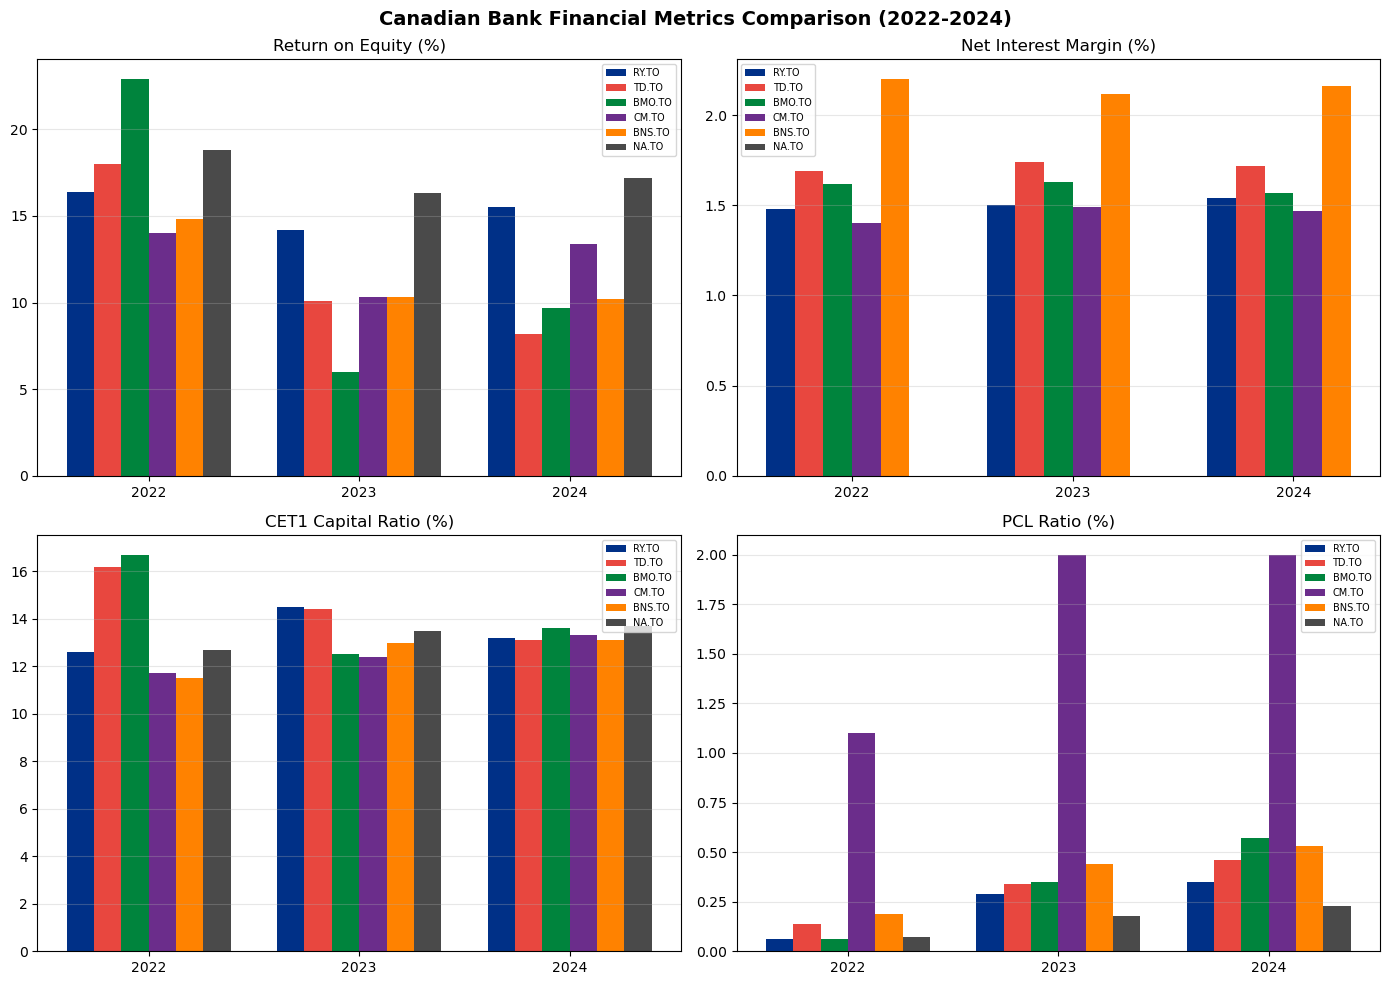

In [48]:
import matplotlib.pyplot as plt
import numpy as np

banks = df['Bank'].unique()
metrics = {'ROE': 'Return on Equity (%)', 
           'NIM': 'Net Interest Margin (%)', 
           'CET1': 'CET1 Capital Ratio (%)', 
           'PCL_ratio': 'PCL Ratio (%)'}

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
axes = axes.flatten()

colors = ['#003087', '#E8473F', '#00843D', '#6B2D8B', '#FF8200', '#4A4A4A']

for idx, (metric, title) in enumerate(metrics.items()):
    ax = axes[idx]
    x = np.arange(3)  # 3年
    width = 0.13      # 每个bar的宽度
    
    for i, bank in enumerate(banks):
        bank_data = df[df['Bank'] == bank].sort_values('Year')
        values = bank_data[metric].values
        ax.bar(x + i * width, values, width, label=bank, color=colors[i])
    
    ax.set_title(title)
    ax.set_xticks(x + width * 2.5)
    ax.set_xticklabels(['2022', '2023', '2024'])
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3, axis='y')

plt.suptitle('Canadian Bank Financial Metrics Comparison (2022-2024)', 
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('financial_metrics.png', dpi=150)
plt.show()

In [49]:
import sqlite3

conn = sqlite3.connect('canadian_banks.db')

# 存财务数据
df.to_sql('financials', conn, if_exists='replace', index=False)

# 存股价数据（只存收盘价）
close_reset = close.reset_index()
close_long = close_reset.melt(id_vars='Date', var_name='Ticker', value_name='Close_Price')
close_long.to_sql('stock_prices', conn, if_exists='replace', index=False)

print("数据库建好了")
conn.close()

数据库建好了


In [50]:
conn = sqlite3.connect('canadian_banks.db')

# Query 1: ROE ranking by year
print("=== ROE Ranking by Year ===")
query1 = pd.read_sql("""
    SELECT Bank, Year, ROUND(ROE, 2) as ROE
    FROM financials
    ORDER BY Year, ROE DESC
""", conn)
print(query1)

# Query 2: High PCL ratio alert (>0.3%)
print("\n=== High PCL Risk Alert (>0.3%) ===")
query2 = pd.read_sql("""
    SELECT Bank, Year, ROUND(PCL_ratio, 2) as PCL_ratio
    FROM financials
    WHERE PCL_ratio > 0.3
    ORDER BY PCL_ratio DESC
""", conn)
print(query2)

# Query 3: Average CET1 ratio over 3 years
print("\n=== 3-Year Average CET1 Ratio ===")
query3 = pd.read_sql("""
    SELECT Bank, ROUND(AVG(CET1), 2) as Avg_CET1
    FROM financials
    GROUP BY Bank
    ORDER BY Avg_CET1 DESC
""", conn)
print(query3)

conn.close()

=== ROE Ranking by Year ===
      Bank  Year   ROE
0   BMO.TO  2022  22.9
1    NA.TO  2022  18.8
2    TD.TO  2022  18.0
3    RY.TO  2022  16.4
4   BNS.TO  2022  14.8
5    CM.TO  2022  14.0
6    NA.TO  2023  16.3
7    RY.TO  2023  14.2
8    CM.TO  2023  10.3
9   BNS.TO  2023  10.3
10   TD.TO  2023  10.1
11  BMO.TO  2023   6.0
12   NA.TO  2024  17.2
13   RY.TO  2024  15.5
14   CM.TO  2024  13.4
15  BNS.TO  2024  10.2
16  BMO.TO  2024   9.7
17   TD.TO  2024   8.2

=== High PCL Risk Alert (>0.3%) ===
     Bank  Year  PCL_ratio
0   CM.TO  2023       2.00
1   CM.TO  2024       2.00
2   CM.TO  2022       1.10
3  BMO.TO  2024       0.57
4  BNS.TO  2024       0.53
5   TD.TO  2024       0.46
6  BNS.TO  2023       0.44
7   RY.TO  2024       0.35
8  BMO.TO  2023       0.35
9   TD.TO  2023       0.34

=== 3-Year Average CET1 Ratio ===
     Bank  Avg_CET1
0   TD.TO     14.57
1  BMO.TO     14.27
2   RY.TO     13.43
3   NA.TO     13.30
4  BNS.TO     12.53
5   CM.TO     12.47
